In [1]:
# Doclayout-yolo 모델 기반 논문 칼럼 레이아웃 감지기
# https://github.com/opendatalab/DocLayout-YOLO?tab=readme-ov-file

# !pip install -qU doclayout-yolo pymupdf pillow

In [2]:
import os
import json
from datetime import datetime

import fitz                       # PDF 읽기 (PyMuPDF)
from PIL import Image              # 이미지 처리
from doclayout_yolo import YOLOv10 # DocLayout-YOLO 모델

/opt/anaconda3/envs/LLMEnv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
PDF_PATH    = "./Documents/1950230.pdf"           # 테스트할 PDF 파일 경로 
PDF_DIR     = "./Documents/"                      # 배치 처리할 폴더  
OUTPUT_JSON = "./paper-layout-classifier-results.json"         # 결과 저장 파일 경로

MAX_PAGES   = 5      # PDF당 분석할 최대 페이지 수
DPI         = 150    # 이미지 해상도 (크면 정확하지만 느림)
CONF        = 0.2    # YOLO 감지 신뢰도 임계값 (낮을수록 더 많이 감지)

# 2단 판정 기준:
# 전체 페이지 중 이 비율 이상이 2단으로 감지되면 최종 '2단 논문'으로 판정
MULTI_COL_THRESHOLD = 0.3

---
## Step 1. 모델 불러오기

HuggingFace에서 **DocLayout-YOLO-DocStructBench** 모델을 자동으로 다운로드합니다.  
처음 실행 시 다운로드가 진행되며, 이후에는 캐시에서 불러옵니다.

In [4]:
from huggingface_hub import hf_hub_download

# HuggingFace에서 모델 가중치 파일(.pt)을 직접 다운로드
# 처음 실행 시 다운로드, 이후엔 캐시(~/.cache/huggingface/hub)에서 불러옴
model_path = hf_hub_download(
    repo_id="juliozhao/DocLayout-YOLO-DocStructBench",
    filename="doclayout_yolo_docstructbench_imgsz1024.pt",
)
print(f"모델 파일 경로: {model_path}")

# 다운로드된 .pt 파일로 모델 로드
model = YOLOv10(model_path)

print("\n모델 로드 완료!")
print("\n감지 가능한 클래스:")
for idx, name in model.names.items():
    print(f"  {idx}: {name}")

모델 파일 경로: /Users/baekseungju/.cache/huggingface/hub/models--juliozhao--DocLayout-YOLO-DocStructBench/snapshots/8c3299a30b8ff29a1503c4431b035b93220f7b11/doclayout_yolo_docstructbench_imgsz1024.pt

모델 로드 완료!

감지 가능한 클래스:
  0: title
  1: plain text
  2: abandon
  3: figure
  4: figure_caption
  5: table
  6: table_caption
  7: table_footnote
  8: isolate_formula
  9: formula_caption


---
## Step 2. PDF 페이지를 이미지로 변환해서 확인하기

이미지 크기: (1251, 1650)  (가로 x 세로 픽셀)


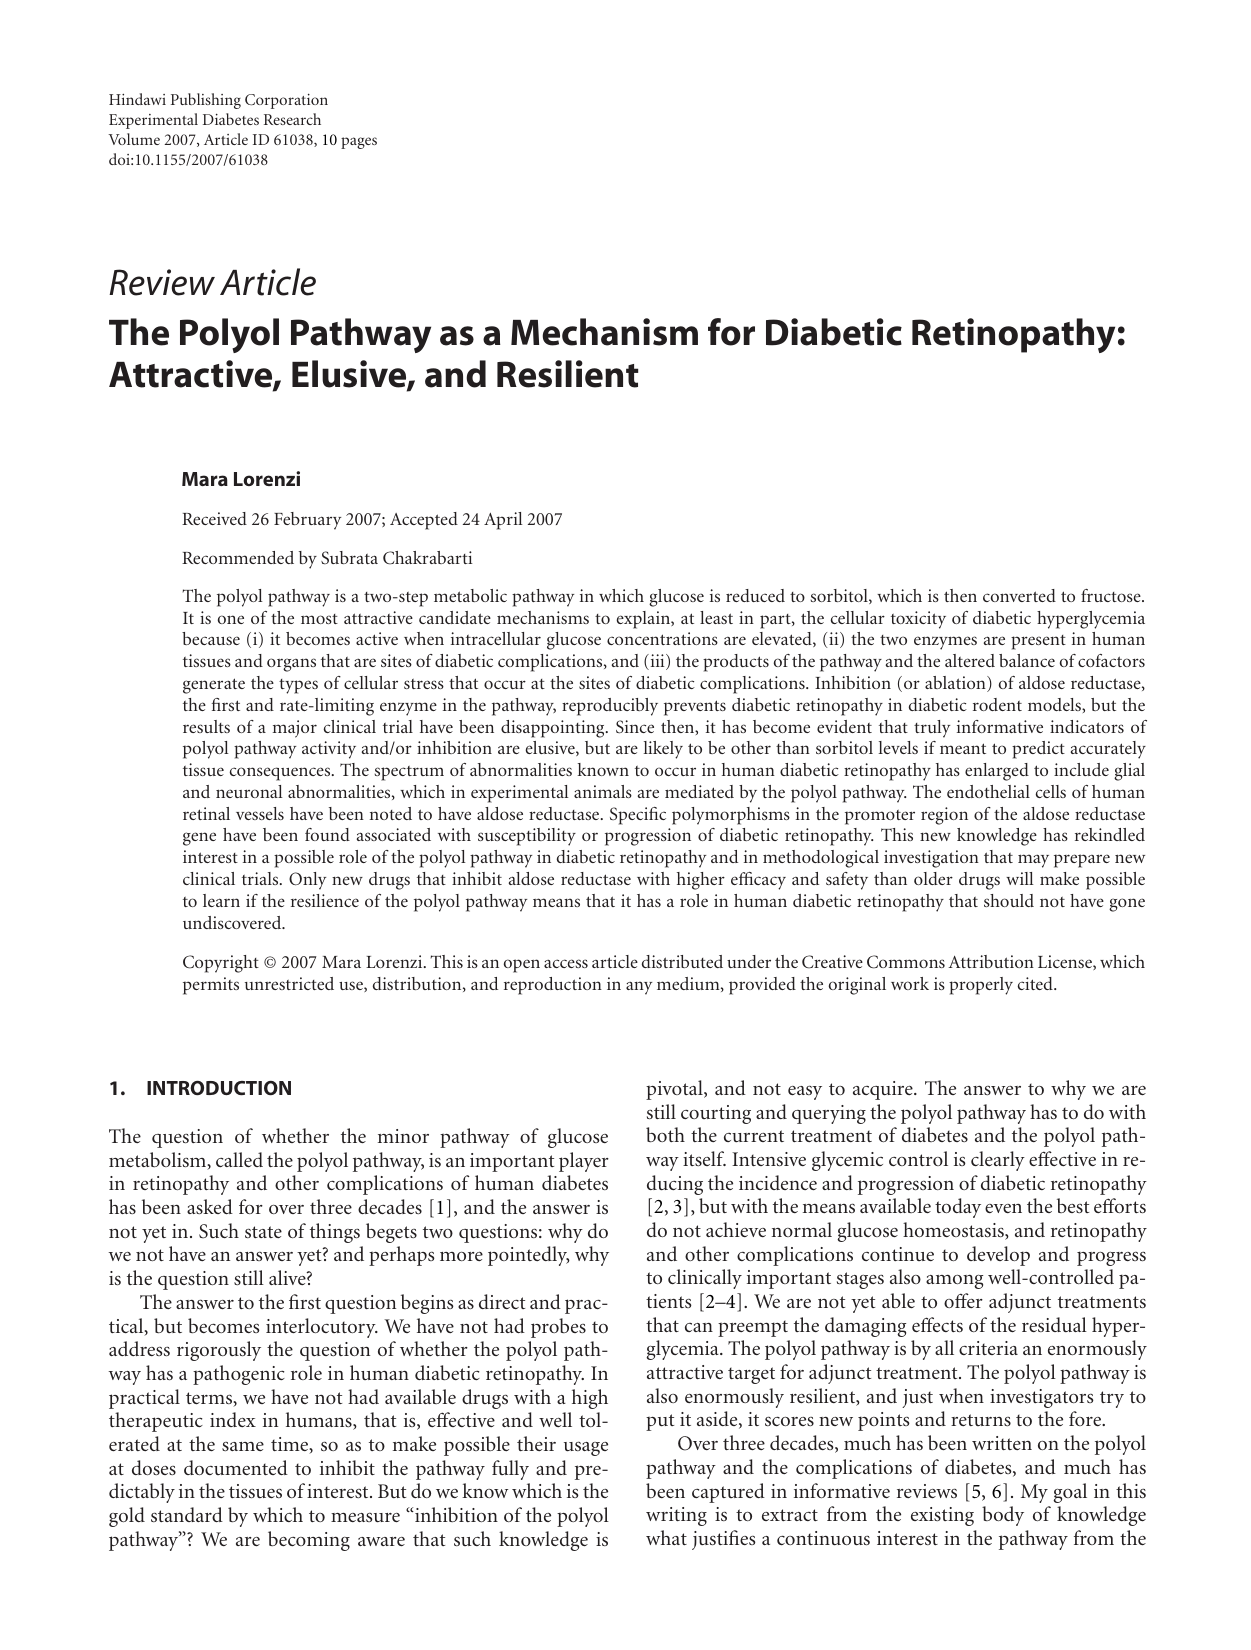

In [5]:
# PDF를 열고 첫 번째 페이지를 이미지로 변환
doc = fitz.open(PDF_PATH)
page = doc[0]  # 0 = 첫 번째 페이지

# 페이지 → 이미지 변환 (DPI 값으로 해상도 결정)
zoom = DPI / 72.0  # PDF 기본 해상도는 72dpi
pixmap = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), colorspace=fitz.csRGB)
img = Image.frombytes("RGB", (pixmap.width, pixmap.height), pixmap.samples)

doc.close()

print(f"이미지 크기: {img.size}  (가로 x 세로 픽셀)")
display(img)

---
## Step 3. YOLO로 레이아웃 요소 감지하기 (단일 페이지)

YOLO가 페이지에서 텍스트 블록, 제목, 그림 등의 **위치(바운딩 박스)**를 찾아냅니다.

In [6]:
# YOLO 추론 실행
# imgsz=1024: 모델 입력 해상도 (논문 권장값)
det_res = model.predict(img, imgsz=1024, conf=CONF, verbose=False)

# 감지 결과가 담긴 객체
result = det_res[0]

print(f"감지된 요소 수: {len(result.boxes)}개\n")

# 각 감지 요소의 정보 출력
for box in result.boxes:
    cls_id  = int(box.cls)           # 클래스 번호
    cls_name = model.names[cls_id]   # 클래스 이름
    conf    = float(box.conf)        # 신뢰도 (0~1)
    x1, y1, x2, y2 = box.xyxy[0].tolist()  # 바운딩 박스 좌표
    print(f"  [{cls_name:15s}] 신뢰도: {conf:.2f}  위치: ({x1:.0f}, {y1:.0f}) ~ ({x2:.0f}, {y2:.0f})")

감지된 요소 수: 16개

  [plain text     ] 신뢰도: 0.98  위치: (181, 585) ~ (1148, 933)
  [plain text     ] 신뢰도: 0.98  위치: (108, 1293) ~ (609, 1552)
  [plain text     ] 신뢰도: 0.98  위치: (109, 1125) ~ (609, 1289)
  [plain text     ] 신뢰도: 0.98  위치: (645, 1077) ~ (1148, 1430)
  [plain text     ] 신뢰도: 0.98  위치: (645, 1433) ~ (1148, 1551)
  [abandon        ] 신뢰도: 0.95  위치: (108, 91) ~ (379, 169)
  [title          ] 신뢰도: 0.94  위치: (109, 312) ~ (1127, 395)
  [plain text     ] 신뢰도: 0.93  위치: (180, 951) ~ (1147, 996)
  [plain text     ] 신뢰도: 0.91  위치: (181, 547) ~ (474, 568)
  [title          ] 신뢰도: 0.90  위치: (109, 1076) ~ (293, 1100)
  [plain text     ] 신뢰도: 0.82  위치: (181, 508) ~ (563, 530)
  [plain text     ] 신뢰도: 0.57  위치: (181, 508) ~ (564, 530)
  [title          ] 신뢰도: 0.50  위치: (180, 466) ~ (301, 491)
  [plain text     ] 신뢰도: 0.46  위치: (109, 264) ~ (320, 301)
  [plain text     ] 신뢰도: 0.44  위치: (180, 466) ~ (301, 491)
  [title          ] 신뢰도: 0.29  위치: (109, 264) ~ (320, 301)


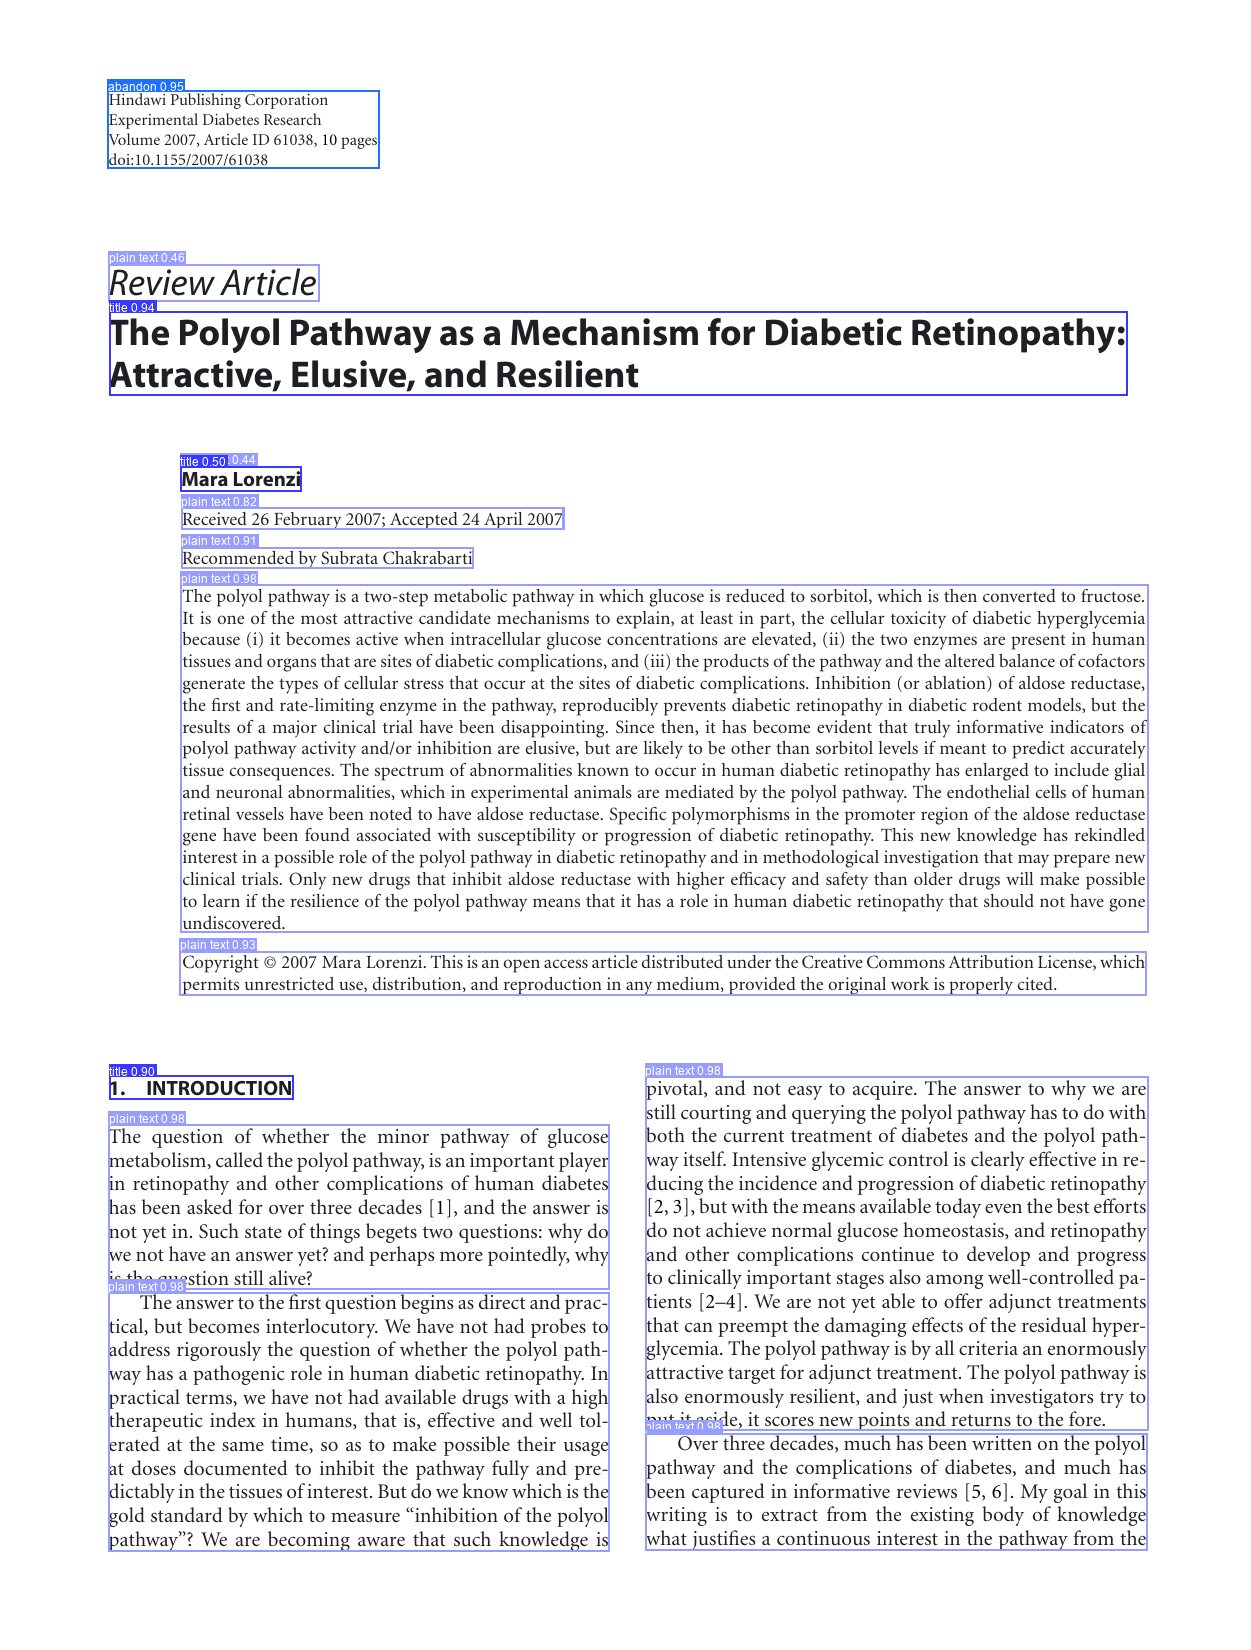

In [7]:
# 감지 결과를 이미지 위에 시각화
# (바운딩 박스와 클래스 이름이 표시됨)
annotated = result.plot(pil=True, line_width=2, font_size=12)
annotated_img = Image.fromarray(annotated)
display(annotated_img)

---
## Step 4. 감지 결과로 칼럼 수 판단하기

### 판단 원리

```
페이지 가로 폭을 0~1로 정규화했을 때:

  1단 논문:  [      텍스트 블록 (x_center ≈ 0.5)      ]
  
  2단 논문:  [ 텍스트(≈0.25) ]   [ 텍스트(≈0.75) ]
               ↑ 왼쪽 그룹           ↑ 오른쪽 그룹
```

텍스트 박스 중심의 x좌표가 **왼쪽 절반**과 **오른쪽 절반** 모두에 분포하면 → **2단**  
한쪽에만 몰려있으면 → **1단**

In [8]:
def page_column_analysis(det_result, img_width):
    """
    YOLO 감지 결과에서 텍스트 박스의 x좌표 분포를 분석해 칼럼 수를 판정합니다.

    반환값: 1 (1단), 2 (2단), None (텍스트 박스가 없어서 판단 불가)
    """

    # 실제 모델 클래스 이름에 맞게 설정
    # 'abandon'은 머리말/꼬리말/페이지 번호 등 무관한 요소라 제외
    TEXT_CLASSES = {"plain text", "title"}

    # 텍스트 박스들의 x 중심값 수집 (0~1 정규화)
    x_centers = []
    for box in det_result.boxes:
        cls_name = model.names[int(box.cls)]
        if cls_name in TEXT_CLASSES:
            x1, _, x2, _ = box.xyxy[0].tolist()
            x_center = ((x1 + x2) / 2) / img_width  # 0~1로 정규화
            x_centers.append(x_center)

    if not x_centers:
        return None  # 텍스트 박스 없음

    # 왼쪽 절반(< 0.45)과 오른쪽 절반(> 0.55)에 박스가 있는지 확인
    # 0.45~0.55 구간은 중앙 여백(거터)으로 제외
    left_count  = sum(1 for x in x_centers if x < 0.45)
    right_count = sum(1 for x in x_centers if x > 0.55)

    print(f"    텍스트 박스: 총 {len(x_centers)}개 | 왼쪽: {left_count}개 | 오른쪽: {right_count}개")

    # 좌우 양쪽에 모두 박스가 있으면 2단
    if left_count >= 1 and right_count >= 1:
        return 2
    else:
        return 1


# --- 테스트 ---
columns = page_column_analysis(result, img.width)
print(f"    → 판정: {columns}단")

    텍스트 박스: 총 15개 | 왼쪽: 10개 | 오른쪽: 2개
    → 판정: 2단


---
## PDF 파일 하나 전체 분석하기

In [9]:
def PDF_analysis(pdf_path):
    """PDF 파일 하나를 여러 페이지에 걸쳐 분석하고 레이아웃을 판정합니다."""

    doc = fitz.open(pdf_path)
    total = len(doc)
    print(f"총 {total}페이지 | 최대 {MAX_PAGES}페이지 분석")

    # 균등하게 페이지 선택 (첫 페이지 포함)
    if total <= MAX_PAGES:
        page_indices = list(range(total))
    else:
        step = total / (MAX_PAGES - 1)
        page_indices = sorted(set(
            [0] + [min(int(i * step), total - 1) for i in range(1, MAX_PAGES)]
        ))

    page_labels = []  # 각 페이지의 판정 결과 저장

    for idx in page_indices:
        print(f"  페이지 {idx+1} 분석 중...")

        # 페이지 → 이미지 변환
        page = doc[idx]
        zoom = DPI / 72.0
        pixmap = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), colorspace=fitz.csRGB)
        img = Image.frombytes("RGB", (pixmap.width, pixmap.height), pixmap.samples)

        # YOLO 추론
        det_res = model.predict(img, imgsz=1024, conf=CONF, verbose=False)

        # 칼럼 수 판정
        columns = page_column_analysis(det_res[0], img.width)
        print(f"    → {columns}단")

        page_labels.append(columns)

    doc.close()

    # 전체 페이지 중 2단 비율이 MULTI_COL_THRESHOLD 이상이면 2단 논문으로 판정
    valid = [c for c in page_labels if c is not None]
    if not valid:
        return "판단 불가"

    ratio = sum(1 for c in valid if c == 2) / len(valid)
    print(f"\n  2단 비율: {ratio:.0%} ({sum(1 for c in valid if c == 2)}/{len(valid)} 페이지)")

    return "2단 (multi_column)" if ratio >= MULTI_COL_THRESHOLD else "1단 (single_column)"


# --- 실행 ---
print(f"분석 시작: {PDF_PATH}\n")
layout = PDF_analysis(PDF_PATH)
print(f"\n최종 판정: {layout}")

분석 시작: ./Documents/1950230.pdf

총 10페이지 | 최대 5페이지 분석
  페이지 1 분석 중...
    텍스트 박스: 총 15개 | 왼쪽: 10개 | 오른쪽: 2개
    → 2단
  페이지 3 분석 중...
    텍스트 박스: 총 6개 | 왼쪽: 4개 | 오른쪽: 2개
    → 2단
  페이지 6 분석 중...
    텍스트 박스: 총 7개 | 왼쪽: 3개 | 오른쪽: 4개
    → 2단
  페이지 8 분석 중...
    텍스트 박스: 총 2개 | 왼쪽: 1개 | 오른쪽: 1개
    → 2단
  페이지 10 분석 중...
    텍스트 박스: 총 3개 | 왼쪽: 3개 | 오른쪽: 0개
    → 1단

  2단 비율: 80% (4/5 페이지)

최종 판정: 2단 (multi_column)


---
## 폴더 안의 PDF 전체 배치 처리하기

In [10]:
# 폴더 안의 PDF 파일 목록 수집
pdf_files = sorted([f for f in os.listdir(PDF_DIR) if f.lower().endswith(".pdf")])
print(f"총 {len(pdf_files)}개 PDF 발견\n")

all_results = []

for i, filename in enumerate(pdf_files, 1):
    path = os.path.join(PDF_DIR, filename)
    print(f"[{i}/{len(pdf_files)}] {filename}")

    layout = PDF_analysis(path)
    print(f"  → 최종 판정: {layout}\n" + "-" * 50)

    all_results.append({"file": filename, "layout": layout})

# 결과를 JSON 파일로 저장
output = {
    "timestamp": datetime.now().isoformat(),
    "total": len(all_results),
    "results": all_results,
}
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"\n결과 저장 완료: {OUTPUT_JSON}")

총 5개 PDF 발견

[1/5] 1950230.pdf
총 10페이지 | 최대 5페이지 분석
  페이지 1 분석 중...
    텍스트 박스: 총 15개 | 왼쪽: 10개 | 오른쪽: 2개
    → 2단
  페이지 3 분석 중...
    텍스트 박스: 총 6개 | 왼쪽: 4개 | 오른쪽: 2개
    → 2단
  페이지 6 분석 중...
    텍스트 박스: 총 7개 | 왼쪽: 3개 | 오른쪽: 4개
    → 2단
  페이지 8 분석 중...
    텍스트 박스: 총 2개 | 왼쪽: 1개 | 오른쪽: 1개
    → 2단
  페이지 10 분석 중...
    텍스트 박스: 총 3개 | 왼쪽: 3개 | 오른쪽: 0개
    → 1단

  2단 비율: 80% (4/5 페이지)
  → 최종 판정: 2단 (multi_column)
--------------------------------------------------
[2/5] 2216058.pdf
총 14페이지 | 최대 5페이지 분석
  페이지 1 분석 중...
    텍스트 박스: 총 17개 | 왼쪽: 10개 | 오른쪽: 4개
    → 2단
  페이지 4 분석 중...
    텍스트 박스: 총 14개 | 왼쪽: 7개 | 오른쪽: 7개
    → 2단
  페이지 8 분석 중...
    텍스트 박스: 총 4개 | 왼쪽: 3개 | 오른쪽: 1개
    → 2단
  페이지 11 분석 중...
    텍스트 박스: 총 2개 | 왼쪽: 1개 | 오른쪽: 1개
    → 2단
  페이지 14 분석 중...
    텍스트 박스: 총 5개 | 왼쪽: 5개 | 오른쪽: 0개
    → 1단

  2단 비율: 80% (4/5 페이지)
  → 최종 판정: 2단 (multi_column)
--------------------------------------------------
[3/5] 3542016.pdf
총 4페이지 | 최대 5페이지 분석
  페이지 1 분석 중...
    텍스트 박스: 총 17개 | 왼쪽: 7개 | 

In [ ]:
# 저장된 결과 요약 출력
with open(OUTPUT_JSON, encoding="utf-8") as f:
    data = json.load(f)

single = sum(1 for r in data["results"] if "single" in r["layout"])
multi  = sum(1 for r in data["results"] if "multi"  in r["layout"])
unknown = data["total"] - single - multi

print(f"분석 시각:   {data['timestamp']}")
print(f"총 파일:     {data['total']}개")
print(f"1단 논문:    {single}개")
print(f"2단 논문:    {multi}개")
print(f"판단 불가:   {unknown}개")
print()

for r in data["results"]:
    print(f"  {r['file']:40s} → {r['layout']}")